In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
# Load dataset

data = pd.read_csv('BostonHousing.csv')

# Display first 5 rows
print(data.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [3]:
# Dataset information
print(data.info())

# Check missing values
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [4]:
# Features and target

X = data.drop('medv', axis=1)
y = data['medv']

In [5]:
# Split into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (404, 13)
Testing Data Shape: (102, 13)


In [6]:
# Standardize the data

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [7]:
# Build DNN model

model = Sequential()

# Input layer + Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1))

In [8]:
# Compile model

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Model summary
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                896       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3009 (11.75 KB)
Trainable params: 3009 (11.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
# Train model

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100


21/21 [==============================] - 1s 14ms/step - loss: 596.6756 - mae: 22.5008 - val_loss: 508.1402 - val_mae: 20.9781
Epoch 2/100
21/21 [==============================] - 0s 3ms/step - loss: 531.1180 - mae: 21.0249 - val_loss: 440.8743 - val_mae: 19.3680
Epoch 3/100
21/21 [==============================] - 0s 3ms/step - loss: 445.2086 - mae: 18.9733 - val_loss: 345.9327 - val_mae: 16.8982
Epoch 4/100
21/21 [==============================] - 0s 3ms/step - loss: 325.4500 - mae: 15.7838 - val_loss: 226.6010 - val_mae: 13.2614
Epoch 5/100
21/21 [==============================] - 0s 3ms/step - loss: 194.8036 - mae: 11.6176 - val_loss: 114.8996 - val_mae: 8.7706
Epoch 6/100
21/21 [==============================] - 0s 3ms/step - loss: 100.0531 - mae: 7.7931 - val_loss: 53.5146 - val_mae: 5.1811
Epoch 7/100
21/21 [==============================] - 0s 4ms/step - loss: 57.4525 - mae: 5.8378 - val_loss: 35.5203 - val_mae: 4.0186
Epoch 8/100
21/21 [===========================

In [10]:
# Evaluate model

loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 [==============================] - 0s 2ms/step - loss: 13.1991 - mae: 2.4280
Test Loss (MSE): 13.199076652526855
Test MAE: 2.4280178546905518


In [11]:
# Predictions

y_pred = model.predict(X_test)

print("Predicted Prices:")
print(y_pred[:5])

4/4 [==============================] - 0s 2ms/step
Predicted Prices:
[[28.26965 ]
 [34.800743]
 [18.753181]
 [25.48486 ]
 [16.392342]]


In [12]:
# Performance evaluation

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Squared Error: 13.199076925483883
Root Mean Squared Error: 3.6330533887467005
R2 Score: 0.8200136914165748


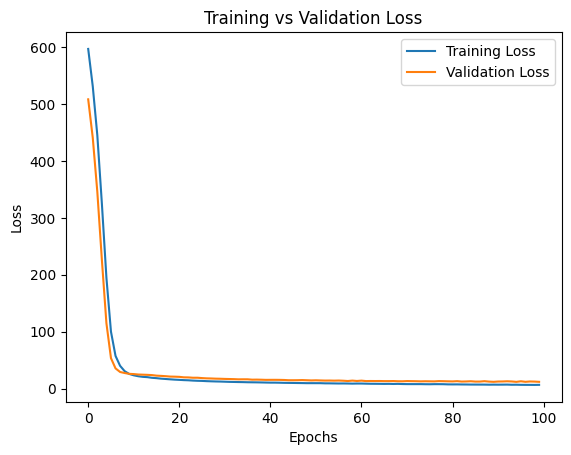

In [13]:
# Plot loss graph

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()